# 🦟 Malaria Detection — Image Classification Project

Proyek ini membangun sistem klasifikasi citra mikroskopis darah menjadi:

- **Uninfected (0)** — sel darah sehat
- **Parasitized (1)** — sel darah terinfeksi malaria

## Strategi proyek

Kita menggunakan **transfer learning sebagai feature extraction** karena dataset berupa citra 224×224 dan ukuran data cukup besar. Backbone pretrained ImageNet akan mengekstrak fitur visual tingkat tinggi seperti tekstur, bentuk, tepi, dan pola sel.

Tiga backbone dibandingkan secara adil:

1. **MobileNetV2** — ringan dan cocok untuk deployment.
2. **EfficientNetB0** — efisien dan biasanya sangat kuat pada klasifikasi citra.
3. **DenseNet121** — sering efektif pada citra medis karena feature reuse.

Model terbaik **tidak diasumsikan di awal**. Notebook memilih model berdasarkan **Validation AUC**, lalu melakukan **fine-tuning** dan evaluasi final pada test set.

> Catatan: proyek ini untuk pembelajaran/eksperimen machine learning dan bukan alat diagnosis medis.

## 1. Import library dan konfigurasi

In [1]:
# Jika berjalan di Google Colab dan library belum tersedia:
# !pip install -q tensorflow scikit-learn matplotlib pandas seaborn pillow streamlit

import os
import gc
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.18.0
GPU        : []


## 2. Konfigurasi lokasi dataset

Struktur folder yang diharapkan:

```text
malaria_dataset/
├── Train/
│   ├── Parasitized/
│   └── Uninfected/
├── Valid/
│   ├── Parasitized/
│   └── Uninfected/
└── Test/
    ├── Parasitized/
    └── Uninfected/
```

Ubah `DATASET_DIR` sesuai lokasi dataset Anda.

In [2]:
# CONTOH COLAB:
# DATASET_DIR = Path("/content/malaria_dataset")

# CONTOH LOKAL:
DATASET_DIR = Path("./malaria_dataset")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Epoch dibuat moderat agar eksperimen tidak terlalu lama.
# Silakan naikkan jika GPU tersedia.
HEAD_EPOCHS = 3
FINE_TUNE_EPOCHS = 5
FINE_TUNE_LAYERS = 30

# Folder output
OUTPUT_DIR = Path("./outputs")
EXPERIMENT_DIR = OUTPUT_DIR / "experiments"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
EXPERIMENT_DIR.mkdir(exist_ok=True, parents=True)

print("Dataset dir:", DATASET_DIR.resolve())

Dataset dir: D:\malaria\malaria_dataset


## 3. Validasi struktur dataset dan hitung jumlah gambar

,Split,Uninfected,Parasitized,Total
0,Train,6582,6570,13152
1,Valid,624,629,1253
2,Test,317,309,626


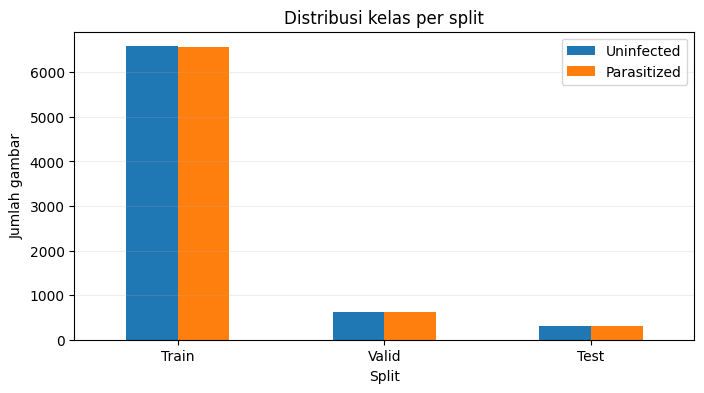

In [3]:
def resolve_split(base_dir: Path, candidates):
    for name in candidates:
        p = base_dir / name
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Tidak menemukan split {candidates} di {base_dir.resolve()}"
    )

train_dir = resolve_split(DATASET_DIR, ["Train", "train"])
valid_dir = resolve_split(DATASET_DIR, ["Valid", "valid", "Validation", "validation"])
test_dir  = resolve_split(DATASET_DIR, ["Test", "test"])

CLASS_NAMES = ["Uninfected", "Parasitized"]
VALID_EXT = {".jpg", ".jpeg", ".png"}

def count_images(split_dir):
    result = {}
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            raise FileNotFoundError(f"Folder kelas tidak ditemukan: {cls_dir}")
        result[cls] = len([
            p for p in cls_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in VALID_EXT
        ])
    return result

counts = []
for split_name, split_dir in [
    ("Train", train_dir),
    ("Valid", valid_dir),
    ("Test", test_dir),
]:
    c = count_images(split_dir)
    counts.append({
        "Split": split_name,
        "Uninfected": c["Uninfected"],
        "Parasitized": c["Parasitized"],
        "Total": c["Uninfected"] + c["Parasitized"],
    })

counts_df = pd.DataFrame(counts)
display(counts_df)

ax = counts_df.set_index("Split")[["Uninfected", "Parasitized"]].plot(
    kind="bar", figsize=(8, 4)
)
ax.set_title("Distribusi kelas per split")
ax.set_ylabel("Jumlah gambar")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=0)
plt.show()

## 4. Pemeriksaan sederhana potensi data leakage

Kita cek apakah ada nama file yang sama antar Train, Valid, dan Test. Ini bukan bukti sempurna terhadap duplikasi citra, tetapi berguna sebagai pemeriksaan awal.

In [4]:
def file_names(split_dir):
    return {
        p.name
        for cls in CLASS_NAMES
        for p in (split_dir / cls).rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXT
    }

train_names = file_names(train_dir)
valid_names = file_names(valid_dir)
test_names = file_names(test_dir)

print("Overlap Train-Valid:", len(train_names & valid_names))
print("Overlap Train-Test :", len(train_names & test_names))
print("Overlap Valid-Test :", len(valid_names & test_names))

Overlap Train-Valid: 0
Overlap Train-Test : 0
Overlap Valid-Test : 0


## 5. Membuat `tf.data.Dataset`

Label sengaja diatur:

- `0 = Uninfected`
- `1 = Parasitized`

Dengan demikian probabilitas keluaran sigmoid dapat dibaca langsung sebagai probabilitas **Parasitized**.

In [5]:
def make_dataset(directory, shuffle=False):
    return keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

train_ds = make_dataset(train_dir, shuffle=True)
valid_ds = make_dataset(valid_dir, shuffle=False)
test_ds  = make_dataset(test_dir, shuffle=False)

# Pipeline performa
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

print("Class order:", CLASS_NAMES)

Found 13152 files belonging to 2 classes.
Found 1253 files belonging to 2 classes.
Found 626 files belonging to 2 classes.
Class order: ['Uninfected', 'Parasitized']


## 6. Visualisasi sampel citra

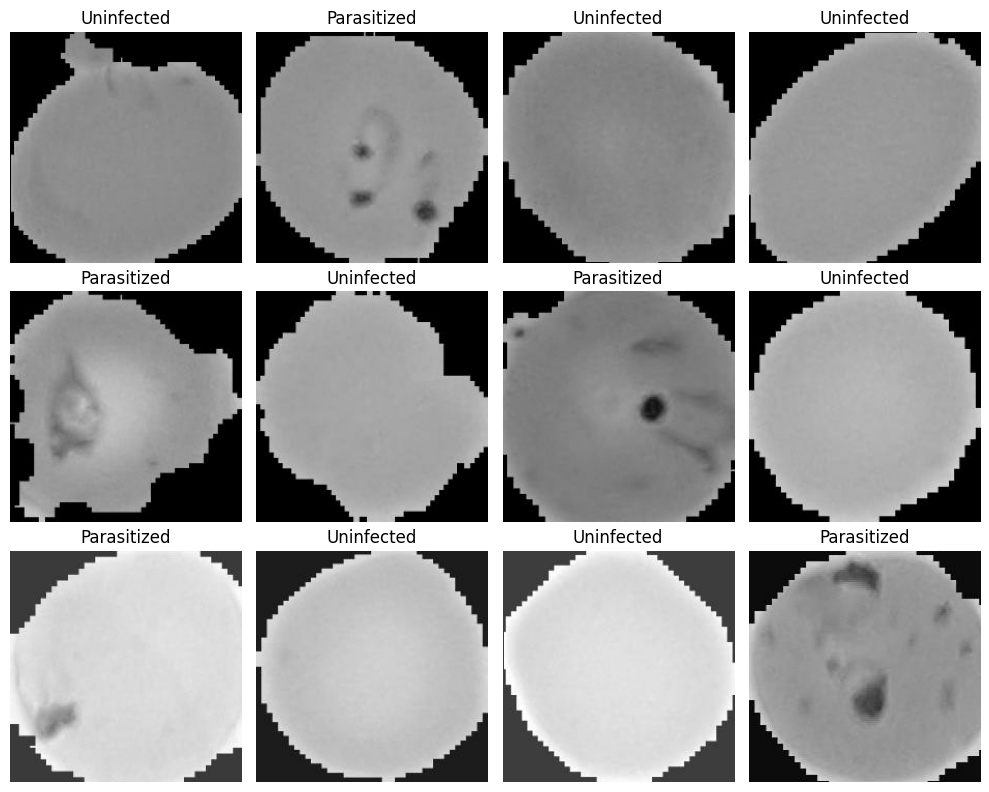

In [6]:
plt.figure(figsize=(10, 8))

images, labels = next(iter(train_ds))
for i in range(min(12, len(images))):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label = int(labels[i].numpy()[0])
    plt.title(CLASS_NAMES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Data augmentation

Augmentasi digunakan **hanya saat training**. Transformasi dibuat relatif ringan agar morfologi sel tidak berubah secara tidak realistis.

In [7]:
def make_augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
        ],
        name="data_augmentation",
    )

## 8. Feature extraction dan kandidat model

### Ekstraksi fitur yang dipilih

Alih-alih menggunakan fitur handcrafted seperti HOG saja, proyek ini menggunakan **deep feature extraction** dari backbone pretrained ImageNet.

Alasannya:

- fitur CNN pretrained lebih kaya dibanding tepi/tekstur sederhana,
- cocok untuk citra 224×224,
- dapat di-fine-tune pada pola spesifik sel darah,
- deployment tetap praktis.

Pada tahap pertama, backbone **dibekukan** sehingga hanya classifier head yang dilatih.

In [8]:
BACKBONES = {
    "MobileNetV2": {
        "constructor": keras.applications.MobileNetV2,
        "preprocess": keras.applications.mobilenet_v2.preprocess_input,
    },
    "EfficientNetB0": {
        "constructor": keras.applications.EfficientNetB0,
        "preprocess": keras.applications.efficientnet.preprocess_input,
    },
    "DenseNet121": {
        "constructor": keras.applications.DenseNet121,
        "preprocess": keras.applications.densenet.preprocess_input,
    },
}

def build_transfer_model(backbone_name: str):
    cfg = BACKBONES[backbone_name]

    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    x = make_augmentation()(inputs)
    x = cfg["preprocess"](x)

    backbone = cfg["constructor"](
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prob_parasitized")(x)

    model = keras.Model(inputs, outputs, name=f"malaria_{backbone_name}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

demo_model = build_transfer_model("EfficientNetB0")
demo_model.summary()
del demo_model
gc.collect()
keras.backend.clear_session()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 19s 1us/step


Model: "malaria_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_parasitized (Dense)        │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 9. Class weight

Jika distribusi kelas tidak seimbang, class weight membantu model agar tidak terlalu bias terhadap kelas mayoritas.

In [9]:
train_count = count_images(train_dir)
n_uninfected = train_count["Uninfected"]
n_parasitized = train_count["Parasitized"]
total = n_uninfected + n_parasitized

class_weight = {
    0: total / (2.0 * n_uninfected),
    1: total / (2.0 * n_parasitized),
}

print("Class weight:", class_weight)

Class weight: {0: 0.9990884229717412, 1: 1.0009132420091325}


## 10. Training feature extractor dan membandingkan backbone

Kriteria pemilihan utama: **Validation AUC**.

AUC dipilih karena menilai kualitas pemisahan dua kelas pada berbagai threshold, bukan hanya satu threshold 0.5.

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=1,
        min_lr=1e-7,
        verbose=1,
    ),
]

experiment_rows = []
history_store = {}

for backbone_name in BACKBONES:
    print("\n" + "=" * 70)
    print(f"Training feature extractor: {backbone_name}")
    print("=" * 70)

    keras.backend.clear_session()
    gc.collect()

    model = build_transfer_model(backbone_name)

    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=HEAD_EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )

    history_store[backbone_name] = history.history

    val_result = model.evaluate(valid_ds, verbose=0, return_dict=True)

    model_path = EXPERIMENT_DIR / f"{backbone_name}.keras"
    model.save(model_path)

    experiment_rows.append({
        "model": backbone_name,
        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"],
        "val_auc": val_result["auc"],
        "val_precision": val_result["precision"],
        "val_recall": val_result["recall"],
        "model_path": str(model_path),
    })

    del model
    gc.collect()

results_df = pd.DataFrame(experiment_rows).sort_values(
    "val_auc", ascending=False
).reset_index(drop=True)

display(results_df)


Training feature extractor: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step
Epoch 1/3
411/411 ━━━━━━━━━━━━━━━━━━━━ 556s 1s/step - accuracy: 0.8101 - auc: 0.8869 - loss: 0.4208 - precision: 0.8181 - recall: 0.7908 - val_accuracy: 0.7390 - val_auc: 0.9323 - val_loss: 0.4918 - val_precision: 0.9748 - val_recall: 0.4928 - learning_rate: 0.0010
Epoch 2/3
411/411 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.8647 - auc: 0.9402 - loss: 0.3085 - precision: 0.8794 - recall: 0.8427 - val_accuracy: 0.8117 - val_auc: 0.9379 - val_loss: 0.3916 - val_precision: 0.9580 - val_recall: 0.6534 - learning_rate: 0.0010
Epoch 3/3
411/411 ━━━━━━━━━━━━━━━━━━━━ 433s 984ms/step - accuracy: 0.8738 - auc: 0.9409 - loss: 0.3075 - precision: 0.8880 - recall: 0.8528 - val_accuracy: 0.8069 - val_auc: 0.9409 - val_loss: 0.4084 - val_precision: 0.9618 - val_recall: 0.6407 - learning_rate: 0.0010

Training feature extractor: EfficientNetB0
Epoch 1/3
411/411 ━━━━━━━━━━━━━━━━━━━━ 596s 1s/step - accuracy: 

,model,val_loss,val_accuracy,val_auc,val_precision,val_recall,model_path
0,EfficientNetB0,0.208929,0.916999,0.975117,0.898331,0.941176,outputs\experiments\EfficientNetB0.keras
1,DenseNet121,0.258816,0.888268,0.962843,0.922280,0.848967,outputs\experiments\DenseNet121.keras
2,MobileNetV2,0.408443,0.806864,0.940914,0.961814,0.640700,outputs\experiments\MobileNetV2.keras


## 11. Visualisasi perbandingan kandidat

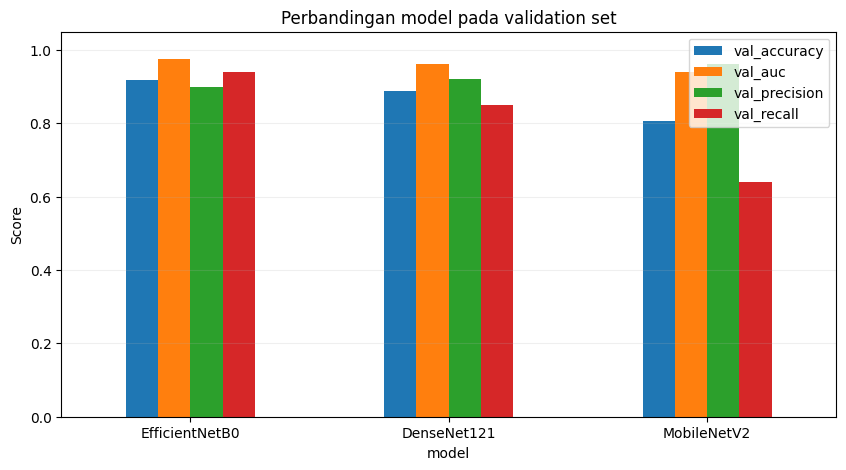

Model terbaik berdasarkan Validation AUC: EfficientNetB0
Path checkpoint: outputs\experiments\EfficientNetB0.keras


In [11]:
plot_df = results_df.set_index("model")[["val_accuracy", "val_auc", "val_precision", "val_recall"]]
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Perbandingan model pada validation set")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.show()

best_name = results_df.loc[0, "model"]
best_path = Path(results_df.loc[0, "model_path"])

print(f"Model terbaik berdasarkan Validation AUC: {best_name}")
print(f"Path checkpoint: {best_path}")

## 12. Fine-tuning model terbaik

Tahap ini membuka sebagian layer terakhir backbone agar fitur ImageNet dapat menyesuaikan diri dengan pola mikroskopis malaria.

Praktik penting:

- hanya sebagian layer akhir yang dibuka,
- layer Batch Normalization tetap dibekukan,
- learning rate dibuat sangat kecil.

In [12]:
best_model = keras.models.load_model(best_path)

# Cari nested pretrained backbone secara robust.
# Di model ini ada dua nested model: data augmentation dan pretrained backbone.
nested_models = [
    layer for layer in best_model.layers
    if isinstance(layer, keras.Model) and layer.name != "data_augmentation"
]

if len(nested_models) == 0:
    raise RuntimeError("Backbone pretrained tidak ditemukan pada model.")

backbone = nested_models[0]
print("Backbone yang di-fine-tune:", backbone.name)

backbone.trainable = True

# Bekukan semua lalu buka hanya N layer terakhir.
for layer in backbone.layers:
    layer.trainable = False

for layer in backbone.layers[-FINE_TUNE_LAYERS:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        OUTPUT_DIR / "malaria_best_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=1,
        min_lr=1e-7,
        verbose=1,
    ),
]

fine_history = best_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=fine_tune_callbacks,
    verbose=1,
)

Backbone yang di-fine-tune: efficientnetb0
Epoch 1/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9017 - auc: 0.9625 - loss: 0.2459 - precision: 0.9052 - recall: 0.8960
Epoch 1: val_auc improved from -inf to 0.97709, saving model to outputs\malaria_best_model.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step - accuracy: 0.9017 - auc: 0.9625 - loss: 0.2459 - precision: 0.9052 - recall: 0.8960 - val_accuracy: 0.9146 - val_auc: 0.9771 - val_loss: 0.2027 - val_precision: 0.9454 - val_recall: 0.8808 - learning_rate: 1.0000e-05
Epoch 2/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9123 - auc: 0.9710 - loss: 0.2170 - precision: 0.9179 - recall: 0.9044
Epoch 2: val_auc improved from 0.97709 to 0.97948, saving model to outputs\malaria_best_model.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 680s 2s/step - accuracy: 0.9124 - auc: 0.9710 - loss: 0.2170 - precision: 0.9179 - recall: 0.9044 - val_accuracy: 0.9258 - val_auc: 0.9795 - val_loss: 0.1866 - val_precision: 0.9452 - val_recall: 0.904

## 13. Kurva training fine-tuning

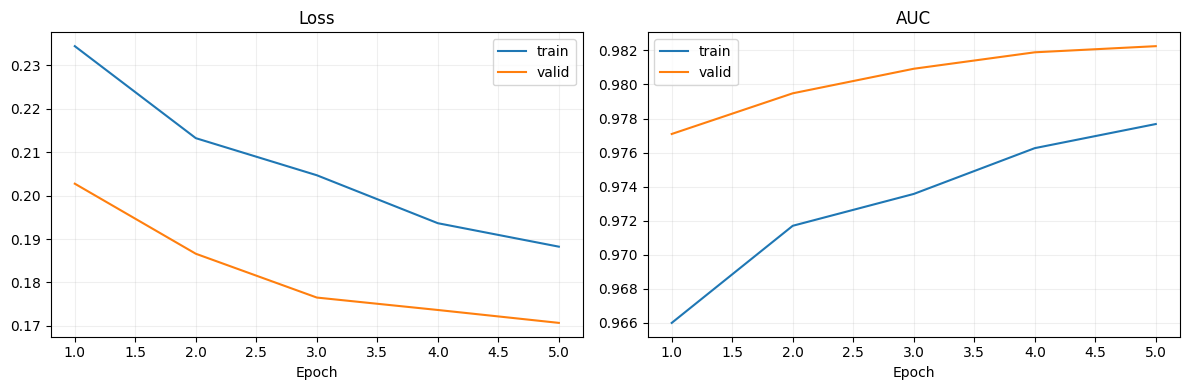

In [13]:
hist = pd.DataFrame(fine_history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist.index + 1, hist["loss"], label="train")
ax[0].plot(hist.index + 1, hist["val_loss"], label="valid")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()
ax[0].grid(alpha=0.2)

ax[1].plot(hist.index + 1, hist["auc"], label="train")
ax[1].plot(hist.index + 1, hist["val_auc"], label="valid")
ax[1].set_title("AUC")
ax[1].set_xlabel("Epoch")
ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 14. Evaluasi final pada Test Set

Test set baru dipakai setelah proses pemilihan model dan fine-tuning selesai.

In [14]:
final_model_path = OUTPUT_DIR / "malaria_best_model.keras"
final_model = keras.models.load_model(final_model_path)

test_result = final_model.evaluate(test_ds, verbose=1, return_dict=True)

print("\n=== Test Metrics ===")
for k, v in test_result.items():
    print(f"{k:>10s}: {v:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9454 - auc: 0.5616 - loss: 0.1425 - precision: 0.4689 - recall: 0.5214

=== Test Metrics ===
  accuracy: 0.9329
       auc: 0.9825
      loss: 0.1712
 precision: 0.9465
    recall: 0.9159


## 15. Classification report dan confusion matrix

              precision    recall  f1-score   support

  Uninfected     0.9205    0.9495    0.9348       317
 Parasitized     0.9465    0.9159    0.9309       309

    accuracy                         0.9329       626
   macro avg     0.9335    0.9327    0.9329       626
weighted avg     0.9333    0.9329    0.9329       626



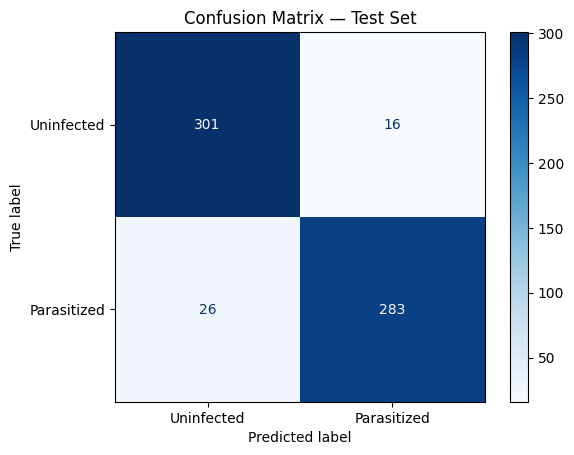

In [15]:
y_true = []
y_prob = []

for batch_images, batch_labels in test_ds:
    probs = final_model.predict(batch_images, verbose=0).ravel()
    y_prob.extend(probs.tolist())
    y_true.extend(batch_labels.numpy().ravel().astype(int).tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Test Set")
plt.show()

## 16. ROC Curve dan Test AUC

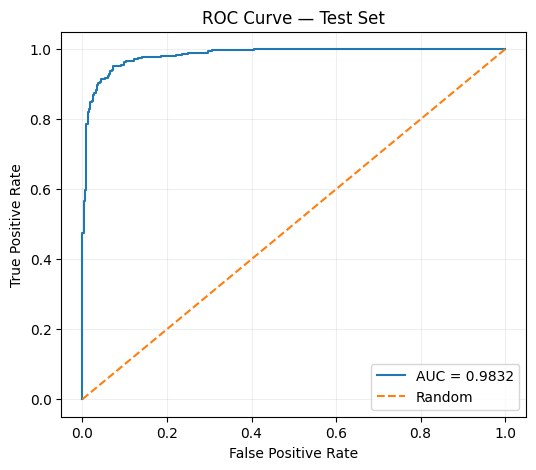

Test ROC-AUC: 0.9832


In [16]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_value = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
plt.plot([0, 1], [0, 1], "--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Test ROC-AUC: {auc_value:.4f}")

## 17. Contoh prediksi beberapa gambar Test

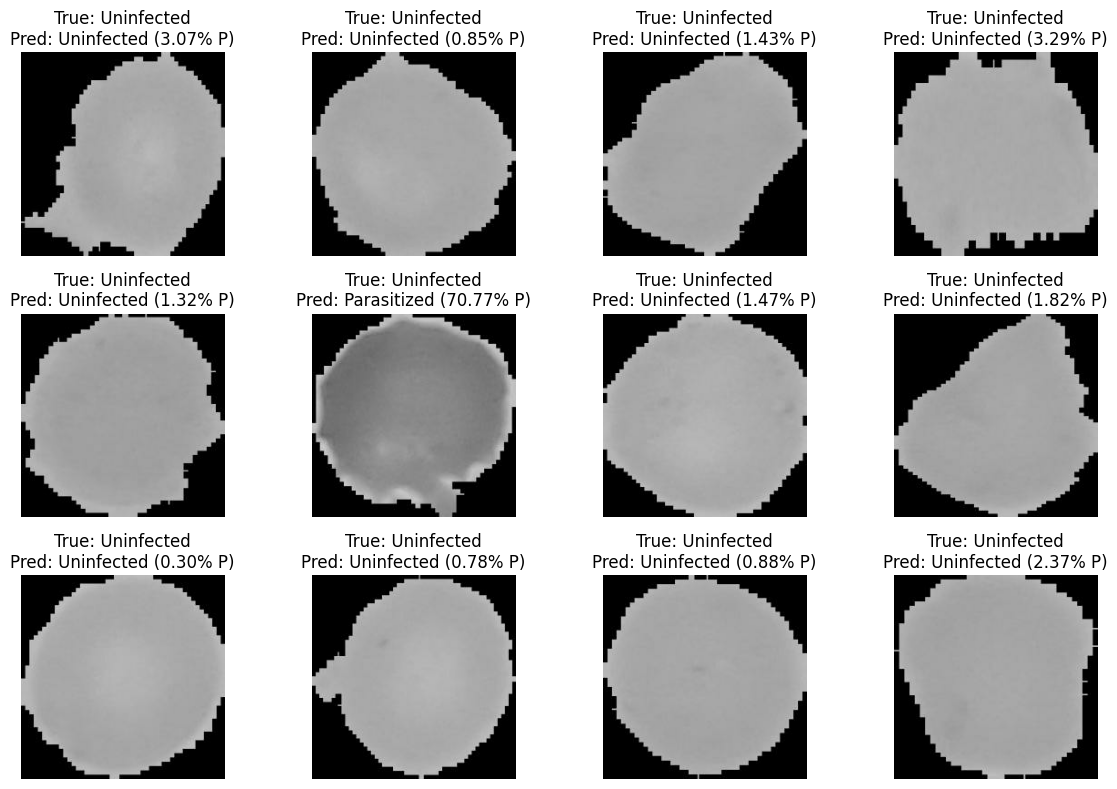

In [17]:
images, labels = next(iter(test_ds))
probs = final_model.predict(images, verbose=0).ravel()

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    pred = int(probs[i] >= 0.5)
    true = int(labels[i].numpy()[0])

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(
        f"True: {CLASS_NAMES[true]}\n"
        f"Pred: {CLASS_NAMES[pred]} ({probs[i]:.2%} P)"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 18. Simpan metadata model

Metadata berguna agar deployment mengetahui urutan kelas dan nama backbone pemenang.

In [18]:
metadata = {
    "class_names": CLASS_NAMES,
    "positive_class": "Parasitized",
    "image_size": list(IMG_SIZE),
    "threshold": 0.5,
    "selected_backbone": best_name,
    "selection_metric": "validation_auc",
    "test_metrics": {k: float(v) for k, v in test_result.items()},
    "test_roc_auc": float(auc_value),
}

with open(OUTPUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))
print("\nModel final :", final_model_path.resolve())

{
  "class_names": [
    "Uninfected",
    "Parasitized"
  ],
  "positive_class": "Parasitized",
  "image_size": [
    224,
    224
  ],
  "threshold": 0.5,
  "selected_backbone": "EfficientNetB0",
  "selection_metric": "validation_auc",
  "test_metrics": {
    "accuracy": 0.9329073429107666,
    "auc": 0.9825477600097656,
    "loss": 0.17122215032577515,
    "precision": 0.9464883208274841,
    "recall": 0.9158576130867004
  },
  "test_roc_auc": 0.983226649515584
}

Model final : D:\malaria\outputs\malaria_best_model.keras


# 19. Streamlit — Deployment

Bagian Streamlit sengaja diletakkan **paling akhir**.

Aplikasi akan:

- menerima upload JPG/JPEG/PNG,
- menampilkan gambar,
- melakukan resize ke 224×224,
- memuat `malaria_best_model.keras`,
- menampilkan kelas prediksi dan probabilitas Parasitized.

Jalankan setelah model selesai dilatih.

In [19]:
%%writefile app.py
import json
from pathlib import Path

import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

st.set_page_config(
    page_title="Malaria Detection",
    page_icon="🦟",
    layout="centered",
)

MODEL_PATH = Path("outputs/malaria_best_model.keras")
META_PATH = Path("outputs/model_metadata.json")

st.title("🦟 Malaria Detection")
st.caption("Klasifikasi citra sel darah: Uninfected vs Parasitized")

st.warning(
    "Aplikasi ini dibuat untuk pembelajaran/eksperimen machine learning "
    "dan bukan alat diagnosis medis."
)

@st.cache_resource
def load_model():
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Model tidak ditemukan di {MODEL_PATH}. "
            "Jalankan notebook training terlebih dahulu."
        )
    return tf.keras.models.load_model(MODEL_PATH)

def load_metadata():
    default = {
        "class_names": ["Uninfected", "Parasitized"],
        "threshold": 0.5,
        "image_size": [224, 224],
    }
    if META_PATH.exists():
        with open(META_PATH, "r") as f:
            return json.load(f)
    return default

metadata = load_metadata()
class_names = metadata["class_names"]
threshold = float(metadata.get("threshold", 0.5))
img_size = tuple(metadata.get("image_size", [224, 224]))

uploaded = st.file_uploader(
    "Upload citra blood smear",
    type=["jpg", "jpeg", "png"],
)

if uploaded is not None:
    image = Image.open(uploaded).convert("RGB")
    st.image(image, caption="Gambar yang diunggah", use_container_width=True)

    if st.button("Prediksi", type="primary", use_container_width=True):
        try:
            model = load_model()

            resized = image.resize(img_size)
            x = np.asarray(resized, dtype=np.float32)
            x = np.expand_dims(x, axis=0)

            probability_parasitized = float(
                model.predict(x, verbose=0)[0][0]
            )

            predicted_class = (
                "Parasitized"
                if probability_parasitized >= threshold
                else "Uninfected"
            )

            st.subheader(f"Hasil: {predicted_class}")

            col1, col2 = st.columns(2)
            col1.metric(
                "Parasitized",
                f"{probability_parasitized:.2%}"
            )
            col2.metric(
                "Uninfected",
                f"{1 - probability_parasitized:.2%}"
            )

            st.progress(
                min(max(probability_parasitized, 0.0), 1.0),
                text="Probabilitas Parasitized"
            )

            if predicted_class == "Parasitized":
                st.error(
                    "Model mendeteksi pola yang lebih konsisten dengan kelas Parasitized."
                )
            else:
                st.success(
                    "Model mendeteksi pola yang lebih konsisten dengan kelas Uninfected."
                )

        except Exception as e:
            st.exception(e)

Overwriting app.py


### Menjalankan Streamlit

Dari terminal pada folder proyek:

```bash
streamlit run app.py
```

Pastikan struktur berikut tersedia:

```text
project/
├── app.py
└── outputs/
    ├── malaria_best_model.keras
    └── model_metadata.json
```